In [97]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV
from sklearn.decomposition import PCA
import seaborn as sns
import matplotlib.pyplot as plt

In [41]:
from sklearn.datasets import load_iris # загрузка датасета Ирис

In [42]:
iris = load_iris()

In [43]:
features_matrix = iris.data
print(f"Shape matrix = {features_matrix.shape}")
print(f"The memory = {features_matrix.nbytes} bytes")

Shape matrix = (150, 4)
The memory = 4800 bytes


In [44]:
target_matrix = np.where(iris.target == 0, 'setosa', np.where(iris.target == 1, 'versicolor', 'virginica'))
print(f"Shape matrix = {target_matrix.shape}")
print(f"The memory = {target_matrix.nbytes} bytes")

Shape matrix = (150,)
The memory = 6000 bytes


In [45]:
print(f"Total memory = {features_matrix.nbytes + target_matrix.nbytes}")

Total memory = 10800


In [46]:
iris_df = pd.DataFrame(data=features_matrix, columns=iris['feature_names'])

In [47]:
iris_df['iris_type'] = iris.target

# 1 эксперимент: нормализация данных от 0 до 1.

In [48]:
X, y = iris_df.drop(columns='iris_type'), iris_df.iris_type

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [49]:
scaler = MinMaxScaler().set_output(transform='pandas')

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [53]:
q25 = iris_df['sepal length (cm)'].quantile(0.25)
q75 = iris_df['sepal length (cm)'].quantile(0.75)

iris_df['sepal_length_quantile'] = iris_df['sepal length (cm)'].apply(lambda x: 'small' if x < q25 else 'medium' if x >= q25 and x <= q75 else 'big')

In [57]:
rf_scaled = RandomForestClassifier(random_state=42).fit(X_train_scaled, y_train)

In [59]:
y_pred = rf_scaled.predict(X_test_scaled)

print(f"Accuracy RF scaled: {accuracy_score(y_pred, y_test)}")

Accuracy RF scaled: 0.9


# Случайный лес (RandomForestClassifier) с нормализацией признаков с помощью MinMaxScaler показал хорошие результаты на тестовой выборке. Модель достигла точности 0.9.

# 2 эксперимент: без нормализации данных.

In [61]:
rf = RandomForestClassifier(random_state=42).fit(X_train, y_train)

y_pred = rf.predict(X_test)

print(f"Accuracy RF: {accuracy_score(y_pred, y_test)}")

Accuracy RF: 0.9


# Вывод: Случайный лес без нормализации признаков показал точность также 0.9 на тестовой выборке. Это подтверждает, что RandomForest устойчив к масштабу признаков и может корректно классифицировать объекты даже без предварительной нормализации.

# 3 эксперимент: поменяем гиперпараметры модели с нормализованными данными.

In [62]:
rf_scaled = RandomForestClassifier(random_state=42)

params = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'bootstrap': [True, False]
}

grid_cv = GridSearchCV(rf_scaled, params, scoring='accuracy', n_jobs=-1, cv=5).fit(X_train_scaled, y_train)

print(f"Best accuracy: {grid_cv.best_score_}")
print(f"Best parameters: {grid_cv.best_params_}")

Best accuracy: 0.9583333333333334
Best parameters: {'bootstrap': True, 'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100}


# Вывод: подбор гиперпараметров заметно улучшил качество модели.

In [80]:
pca = PCA(n_components=2)

In [81]:
X_train_pca = pca.fit_transform(X_train_scaled)

In [103]:
y_pred_names = np.where(y_pred == 0, 'setosa', np.where(y_pred == 1, 'versicolor', 'virginica'))
y_train_names = np.where(y_train == 0, 'setosa', np.where(y_train == 1, 'versicolor', 'virginica'))

<Axes: >

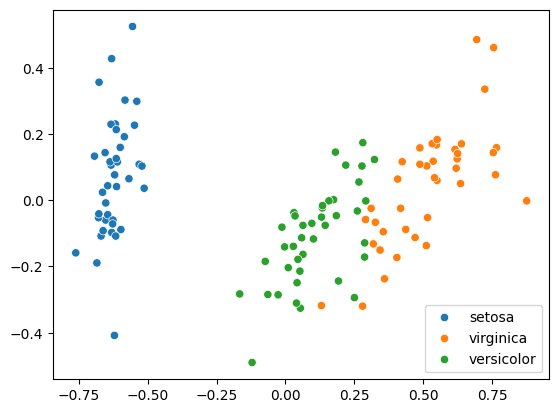

In [109]:
sns.scatterplot(x=X_train_pca[:, 0], y=X_train_pca[:, 1], hue=y_train_names)

In [84]:
X_test_pca = pca.transform(X_test_scaled)

<Axes: >

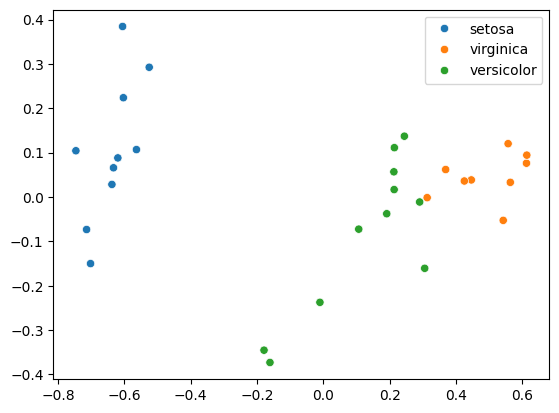

In [108]:
sns.scatterplot(x=X_test_pca[:, 0], y=X_test_pca[:, 1], hue=y_pred_names)